<a href="https://colab.research.google.com/github/phani-x507/DeepLearning/blob/main/02_Neural_network_Classification_with_Pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 # 02. Neural Network Classification with Pytorch
 - It is a problem of prediction whether something is onething or another.

## 1. Make classification Data and get it ready


In [ ]:
import sklearn

In [ ]:
from sklearn.datasets import make_circles

In [ ]:
n_samples = 1000

# Create Circles -. X -> matrix features , y-> labels
X, y = make_circles(n_samples,noise = 0.03, random_state = 42)


In [ ]:
len(X) , len(y)

(1000, 1000)

In [ ]:
print(f"first five samples of X: {X[:5]}")
print(f"first five samples of Y: {y[:5]}")

first five samples of X: [[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]
first five samples of Y: [1 1 1 1 0]


In [ ]:
# From the above there are two labels 0 and one make them binary classification
import pandas as pd
circle_df = pd.DataFrame({"X1":X[:,0], "X2" : X[:,1], "label" : y })
circle_df.head()



,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0


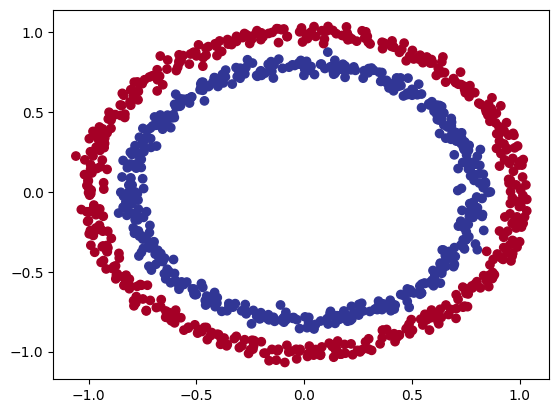

In [ ]:
# Visualize, visualize, Visualize
import matplotlib.pyplot as plt

plt.scatter(X[:,0],X[:,1], c=y ,cmap = plt.cm.RdYlBu);

# You may find the two circles below red and blue, so there are two classes
# the classes are 0 and 1

Note : The date we're working with is often referred to as a toy dataset, a dataset that is small enough to experiment but still sizeable enough to practice the fundamentals.

### 1.1  Check input and Output Shapes

In [ ]:
X.shape , y.shape # X-> 1000 rows and 2 features, y-> 1000 rows and 1 feature

((1000, 2), (1000,))

In [ ]:
# View the first example of features and labels
X_sample = X[0]
y_sample = y[0]
print(f"values of one sample of X:{X_sample} and same for y: {y_sample}")
print(f"Shapes for one sample of X: {X_sample.shape} and the same for y: {y_sample.shape}")
# y is a scalar and if doesnt have a shape

values of one sample of X:[0.75424625 0.23148074] and same for y: 1
Shapes for one sample of X: (2,) and the same for y: ()


In [ ]:
### 1.2 Turn data into tensors and create train and test Splits

In [ ]:
import torch
torch.__version__

'2.10.0+cu128'

In [ ]:
import numpy as np
X = np.float32(X)
X = torch.tensor(X)
y = torch.from_numpy(y).type(torch.float)

In [ ]:
type(X), X.dtype, y.dtype


(torch.Tensor, torch.float32, torch.float32)

In [ ]:
torch.manual_seed(42)



In [ ]:
from sklearn.model_selection import train_test_split

X_train,X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state = 42)

In [ ]:
len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

In [ ]:
n_samples

1000

## 2. Building a model
  Let's build a model to classify our blue and red dot.
  To do so, we want to
  1. Setup Device Agnistic code.
  2. Construct a model (by subclassing `nn.Module`)
  3. Define a loss function and optimizer
  4. Create a trainig and test loop

In [ ]:
import torch
from torch import nn


In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [ ]:
X_train,

(tensor([[ 0.6579, -0.4651],
         [ 0.6319, -0.7347],
         [-1.0086, -0.1240],
         ...,
         [ 0.0157, -1.0300],
         [ 1.0110,  0.1680],
         [ 0.5578, -0.5709]]),)

from sklearn import model_selection
We've setup agnistic code.
1. Subclass `nn.Module`
2. Create 2 `nn.Linear()` layers that are capable of handling the shapes of our data
3. Defines a `forward()` method that outlines the forward pass and forward computation of the model_selection
4. Instantiate the instance of a model class and send it to the target `device`

In [ ]:
class CircleModelV1(nn.Module):
  def __init__(self):
    super().__init__()
    # 2. create two Linear Layers capable of handling the shapes of our data
    self.layer1 =  nn.Linear(in_features=2, out_features=5) # takes input of two features and upscales it to 5.

    self.layer2 = nn.Linear(in_features=5,out_features=1) #it is Output Layer and input features of this layer should be matched to out_features of previous else may get shape mismatch error. and out_features should be equal to shape of y

    #Linear layer performs xA^t+b operation

  def forward(self,x:torch.Tensor) -> torch.Tensor:
    return self.layer2(self.layer1(x)) # x-> layer_1 -> layer2

# 4. Instantiate the instance of our model class and send it to the target device
model_0 = CircleModelV1().to(device)
model_0


CircleModelV1(
  (layer1): Linear(in_features=2, out_features=5, bias=True)
  (layer2): Linear(in_features=5, out_features=1, bias=True)
)

In [ ]:
device

'cuda'

In [ ]:
next(model_0.parameters())

Parameter containing:
tensor([[ 0.5406,  0.5869],
        [-0.1657,  0.6496],
        [-0.1549,  0.1427],
        [-0.3443,  0.4153],
        [ 0.6233, -0.5188]], device='cuda:0', requires_grad=True)

In [ ]:
# Let's Replicate the model about using nn.Sequential()
model_0 = nn.Sequential(
    nn.Linear(in_features =2 , out_features = 5),
    nn.Linear(in_features=5, out_features=1)

    ).to(device)
model_0


Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

In [ ]:
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[-0.0829, -0.2872],
                      [ 0.4691, -0.5582],
                      [-0.3260, -0.1997],
                      [-0.4252,  0.0667],
                      [-0.6984,  0.6386]], device='cuda:0')),
             ('0.bias',
              tensor([-0.6007,  0.5459,  0.1177, -0.2296,  0.4370], device='cuda:0')),
             ('1.weight',
              tensor([[ 0.0697,  0.3613,  0.0489, -0.1410,  0.1202]], device='cuda:0')),
             ('1.bias', tensor([-0.1213], device='cuda:0'))])

In [ ]:

untrained_preds = model_0(X_test.to(device))
torch.round(untrained_preds[:10])

tensor([[-0.],
        [-0.],
        [0.],
        [-0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [-0.]], device='cuda:0', grad_fn=<RoundBackward0>)

### 2.1 Setup loss function and optimizer
  - Which loss funtion or optimizer should you use?
  - This is Problem Specific
  - Example - use MAE or MSE for Regression
  - For Classification -> Binary Cross Entropy or Categorical Cross entropy
  - For Optimizers, two most useful are Adam and SG
  - For Loss function we are going to use `torch.nn.BCDWithLogitLoss()`
  - FOr Different Optimizers see `torch.optim` in web.


In [ ]:
# Loss function
# loss_fn = nn.BCELoss() -> requires to pass thorugh the sigmoid before using this.
# nn.Sequential(
#     nn.Sigmoid(),
#     nn.BCELoss()
# )

loss_fn = nn.BCEWithLogitsLoss() #Sigmoid activation function builtin

#Optimizer
optimizer = torch.optim.SGD(params = model_0.parameters(),
                            lr=0.1)


In [ ]:
#Calculate Accuracy.-  out of 100 examples, what percentage does our model get right?
def accuracy_fn(y_true,y_pred):
  correct = torch.eq(y_true.to(device),y_pred.to(device)).sum().item()

  acc =( correct/len(y_pred))*100

  return acc

In [ ]:
### 3.1 Going from raw Logits -> Prediction Probabilities -> Prediction Labels

model_0.eval()
with torch.inference_mode():
  y_logits = model_0(X_test.to(device))[:5]
y_logits

tensor([[-0.0338],
        [-0.0309],
        [ 0.0894],
        [-0.0692],
        [ 0.2967]], device='cuda:0')

In [ ]:
# Convert logits to Probabilities -> use sigmoid Activation
y_probs = torch.sigmoid(y_logits)
y_probs

tensor([[0.4916],
        [0.4923],
        [0.5223],
        [0.4827],
        [0.5736]], device='cuda:0')

In [ ]:
# Convert Probabilities to Lables -> suchas classes, whether the point belongs to class 0(inner circle) or class 1(outer cirle)
# Use torch.round() to get rounded values if 0 -> class 0, if 1 class 1
y_labels = torch.round(y_probs)
y_labels

tensor([[0.],
        [0.],
        [1.],
        [0.],
        [1.]], device='cuda:0')

In [ ]:
# Writing in full ( logits -> pred probs -> pred labels)
y_pred_labels = torch.round(torch.sigmoid(y_logits.to(device))[:5])

# Check for quality
print(torch.eq(y_labels.squeeze(), y_pred_labels.squeeze()))

# Get rid of extra dimension
y_labels.squeeze()

tensor([True, True, True, True, True], device='cuda:0')


tensor([0., 0., 1., 0., 1.], device='cuda:0')

In [ ]:
# ### 3.2 Building a training and testing loop
# torch.manual_seed(42)
# torch.cuda.manual_seed(42)

# # Set the no of Epochs
# epochs = 2000

# # Put data to target Device
# X_train, y_train = X_train.to(device), y_train.to(device)
# X_test, y_test = X_test.to(device),y_test.to(device)

# # Build training and Evaluation Loop

# for epoch in range(epochs):
#   # Training
#   model_0.train()

#   # Fitting or Forward Pass
#   y_logits = model_0(X_train).squeeze()

#   y_pred = torch.round(torch.sigmoid(y_logits)) # Turn logits -> pred probs -> pred labels

#   # Calculate loss and accuracy
#   #  if loss_fn -> BCELoss()-> expects prediction probabilities as input, so convert logits -> pred probs using sigmoid activation fn
#   loss = loss_fn(y_logits,y_train) # Since we selected BCELossWithLogitsLoss()-> expects logits as parameters

#   acc = accuracy_fn(y_true = y_train, y_pred = y_pred)

#   #Optimizer
#   optimizer.zero_grad()

#   #Loss backward (Backprogration)
#   loss.backward()

#   # Optimizer Step(gradient descent)
#   optimizer.step()

#   # Evaluate Model
#   model_0.eval()
#   with torch.inference_mode():
#     test_logits = model_0(X_test).squeeze()
#     test_probs = torch.sigmoid(test_logits)
#     test_pred = torch.round(torch.sigmoid(test_logits))

#     #2. Calculate the Test loss / Accuracy
#     test_loss = loss_fn(test_logits.squeeze(),y_test)
#     test_acc = accuracy_fn(y_true = y_test, y_pred = test_pred)

#   if epoch %10 == 0:
#     print(f'Epoch : {epoch} | Loss : {loss:.5f} | Acc : {acc:.2f}% | Test loss: {test_loss:.5f} | Test Accuracy : {test_acc:.2f}')


## 4. Make Predictions and evaluate the model,
- From the metrics it looks like our model isn't learning anything.
- So to inspect it let's make some predictions and make them visual



In [ ]:
import requests
from pathlib import Path


if Path("helper_functions.py").is_file():
  print("The file already exists")

else:
  print("Downloading Helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py")
  with open("helper_functions.py","wb") as f:
    f.write(request.content)



The file already exists


In [ ]:
from helper_functions import plot_predictions,plot_decision_boundary

[]

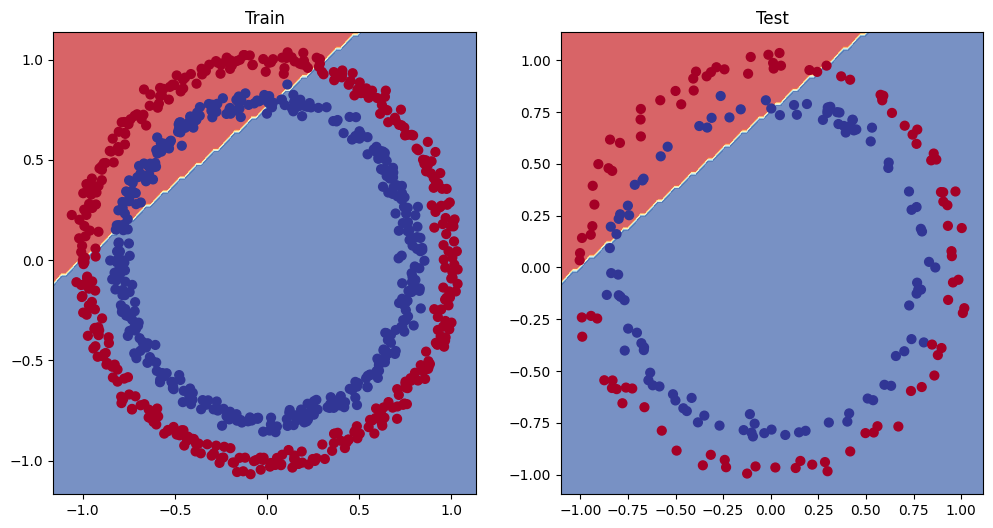

In [ ]:
plt.figure(figsize = (12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_0,X_train,y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_0,X_test,y_test)

plt.plot()


## Improving a model (from a model Perspective)
  - Add more layers - give the model more chances to Learn.
  - Add More Hidden Units - go from 5 hidden units to 10 hidden units.
  - Fit for Longer -> give more epochs.
  - Changing the Activation function .
  - Change the Learning Rate.
  - Change the Loss Function.

These options aare all from a model's perspective because they deal directly with the model, rather than the data.

These all options we refer them as **hyperparameters**.


In [ ]:
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[-0.0829, -0.2872],
                      [ 0.4691, -0.5582],
                      [-0.3260, -0.1997],
                      [-0.4252,  0.0667],
                      [-0.6984,  0.6386]])),
             ('0.bias', tensor([-0.6007,  0.5459,  0.1177, -0.2296,  0.4370])),
             ('1.weight',
              tensor([[ 0.0697,  0.3613,  0.0489, -0.1410,  0.1202]])),
             ('1.bias', tensor([-0.1213]))])

In [ ]:
class CircleModelV2(nn.Module):
  def __init__(self):
    super().__init__()

    self.layer_1 = nn.Linear(in_features = 2 , out_features = 10)

    self.layer_2 = nn.Linear(in_features = 10, out_features = 10)

    self.layer_3 = nn.Linear(in_features = 10 , out_features =1)

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    return self.layer_3(self.layer_2(self.layer_1(x)))

model_1 = CircleModelV2().to(device)

In [ ]:

model_1, model_1.state_dict()

(CircleModelV2(
   (layer_1): Linear(in_features=2, out_features=10, bias=True)
   (layer_2): Linear(in_features=10, out_features=10, bias=True)
   (layer_3): Linear(in_features=10, out_features=1, bias=True)
 ),
 OrderedDict([('layer_1.weight',
               tensor([[ 0.2976,  0.6313],
                       [ 0.4087, -0.3091],
                       [ 0.4082,  0.1265],
                       [ 0.3591, -0.4310],
                       [-0.7000, -0.2732],
                       [-0.5424,  0.5802],
                       [ 0.2037,  0.2929],
                       [ 0.2236, -0.0123],
                       [ 0.5534, -0.5024],
                       [ 0.0445, -0.4826]], device='cuda:0')),
              ('layer_1.bias',
               tensor([ 0.2180, -0.2435,  0.2167, -0.1473,  0.5865, -0.4191, -0.4217, -0.4217,
                        0.6360,  0.2356], device='cuda:0')),
              ('layer_2.weight',
               tensor([[ 0.3043, -0.2610, -0.3137, -0.2474, -0.2127,  0.1281,  0.113

In [ ]:
# Setup Loss Function

loss_fn = nn.BCEWithLogitsLoss()

optimizer = torch.optim.SGD(params = model_1.parameters(), lr=0.1)

In [ ]:

torch.manual_seed(42)
torch.cuda.manual_seed(42)


epochs = 2000

# Put data to target Device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device),y_test.to(device)
for _ in range(epochs):

  model_1.train()

  y_logits = model_1(X_train).squeeze()

  y_pred = torch.round(torch.sigmoid(y_logits))

  loss = loss_fn(y_logits,y_train)

  acc = accuracy_fn(y_train, y_pred)

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  model_1.eval()

  with torch.inference_mode():
    test_logits = model_1(X_test).squeeze()
    test_preds = torch.round(torch.sigmoid(test_logits))

    test_loss = loss_fn(test_logits,y_test)
    test_acc = accuracy_fn(y_true=y_test,y_pred = test_preds)

  if _ %100 == 0:
    print(f'| epoch : {_} | Train loss : {loss:.5f}| Train Accuracy : {acc:.2f} | Test Loss : {test_loss:.5f} | Test Accuracy: {test_acc:.2f} |')

| epoch : 0 | Train loss : 0.69713| Train Accuracy : 50.00 | Test Loss : 0.69594 | Test Accuracy: 50.00 |
| epoch : 100 | Train loss : 0.69327| Train Accuracy : 49.62 | Test Loss : 0.69334 | Test Accuracy: 54.00 |
| epoch : 200 | Train loss : 0.69311| Train Accuracy : 49.88 | Test Loss : 0.69357 | Test Accuracy: 50.00 |
| epoch : 300 | Train loss : 0.69305| Train Accuracy : 50.62 | Test Loss : 0.69384 | Test Accuracy: 49.50 |
| epoch : 400 | Train loss : 0.69301| Train Accuracy : 50.50 | Test Loss : 0.69407 | Test Accuracy: 46.00 |
| epoch : 500 | Train loss : 0.69300| Train Accuracy : 51.00 | Test Loss : 0.69425 | Test Accuracy: 47.50 |
| epoch : 600 | Train loss : 0.69299| Train Accuracy : 51.50 | Test Loss : 0.69438 | Test Accuracy: 47.00 |
| epoch : 700 | Train loss : 0.69298| Train Accuracy : 50.88 | Test Loss : 0.69447 | Test Accuracy: 46.50 |
| epoch : 800 | Train loss : 0.69298| Train Accuracy : 51.00 | Test Loss : 0.69453 | Test Accuracy: 46.00 |
| epoch : 900 | Train loss : 0

[]

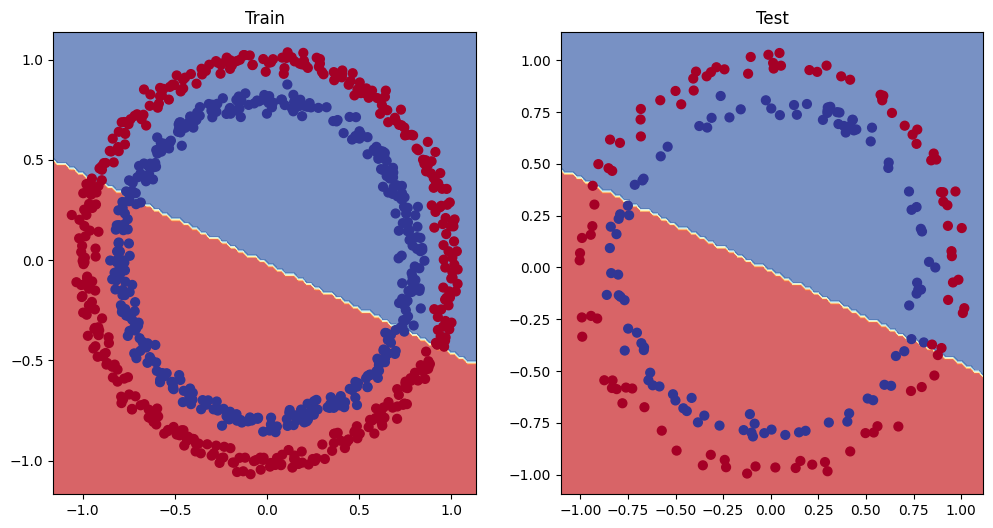

In [ ]:
plt.figure(figsize = (12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_1,X_train,y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_1,X_test,y_test)

plt.plot()


torch.Size([100, 1])

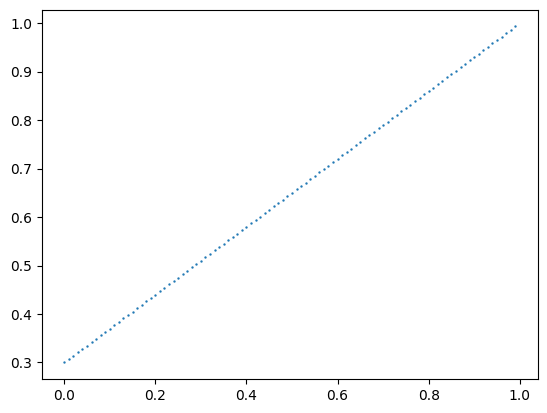

In [ ]:
# The model isn't Learning Anything, Lets build a linear regression with one straight line data.

w = 0.7
b= 0.3

x = torch.arange(0,1,0.01).unsqueeze(dim=1)
y = w*x+b

plt.scatter(x,y , s = 0.5)
x.size()

(torch.Size([80, 1]),
 torch.Size([80, 1]),
 torch.Size([20, 1]),
 torch.Size([20, 1]))

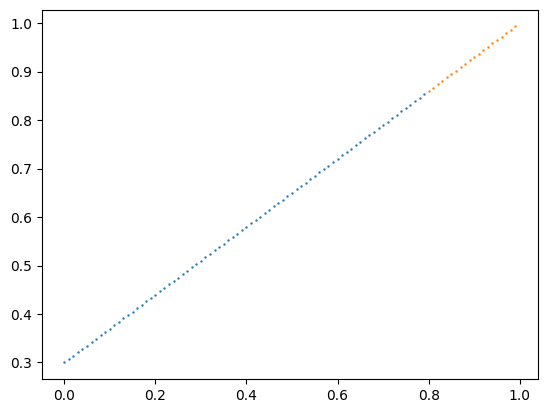

In [ ]:
# Splitting to training and testing
train_split = int(0.8 * len(x))
x_train_reg, y_train_reg = x[:train_split],y[:train_split]
x_test_reg,y_test_reg = x[train_split:],y[train_split:]

plt.scatter(x_train_reg,y_train_reg, s = 0.5)
plt.scatter(x_test_reg,y_test_reg, s=0.5)
x_train_reg.size(), y_train_reg.size() ,x_test_reg.size(),y_test_reg.size()

In [ ]:
class LinearModelV3(nn.Module):
  def __init__(self):
    super().__init__()

    self.layer_1 = nn.Linear(in_features = 1 , out_features = 10)

    self.layer_2 = nn.Linear(in_features = 10, out_features = 10)

    self.layer_3 = nn.Linear(in_features = 10 , out_features =1)

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    return self.layer_3(self.layer_2(self.layer_1(x)))

lin_model = LinearModelV3().to(device)

In [ ]:
lin_model

LinearModelV3(
  (layer_1): Linear(in_features=1, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [ ]:
# Setup Loss Function

loss_fn = nn.L1Loss()

reg_optimizer = torch.optim.SGD(params = lin_model.parameters(), lr=0.001)

In [ ]:

torch.manual_seed(42)
torch.cuda.manual_seed(42)


epochs = 2000

# Put data to target Device
x_train_reg, y_train_reg = x_train_reg.to(device), y_train_reg.to(device)
x_test_reg, y_test_reg = x_test_reg.to(device),y_test_reg.to(device)
for _ in range(epochs):

  lin_model.train()

  y_pred_reg = lin_model(x_train_reg)

  loss = loss_fn(y_pred_reg, y_train_reg)

  reg_optimizer.zero_grad()

  loss.backward()

  reg_optimizer.step()

  lin_model.eval()
  with torch.inference_mode():
    test_pred_reg = lin_model(x_test_reg)
    test_loss = loss_fn(test_pred_reg, y_test_reg)


  if _ %100 == 0:
    print(f'| epoch : {_} | Train loss : {loss:.5f}| Test Loss : {test_loss:.5f} |')

| epoch : 0 | Train loss : 0.75986| Test Loss : 0.94965 |
| epoch : 100 | Train loss : 0.40272| Test Loss : 0.54029 |
| epoch : 200 | Train loss : 0.05876| Test Loss : 0.13480 |
| epoch : 300 | Train loss : 0.01461| Test Loss : 0.03342 |
| epoch : 400 | Train loss : 0.00308| Test Loss : 0.00008 |
| epoch : 500 | Train loss : 0.00309| Test Loss : 0.00012 |
| epoch : 600 | Train loss : 0.00309| Test Loss : 0.00018 |
| epoch : 700 | Train loss : 0.00299| Test Loss : 0.00011 |
| epoch : 800 | Train loss : 0.00299| Test Loss : 0.00016 |
| epoch : 900 | Train loss : 0.00289| Test Loss : 0.00011 |
| epoch : 1000 | Train loss : 0.00289| Test Loss : 0.00015 |
| epoch : 1100 | Train loss : 0.00290| Test Loss : 0.00020 |
| epoch : 1200 | Train loss : 0.00279| Test Loss : 0.00014 |
| epoch : 1300 | Train loss : 0.00280| Test Loss : 0.00019 |
| epoch : 1400 | Train loss : 0.00281| Test Loss : 0.00025 |
| epoch : 1500 | Train loss : 0.00270| Test Loss : 0.00018 |
| epoch : 1600 | Train loss : 0.0027

(torch.Size([20, 1]), torch.Size([20, 1]))

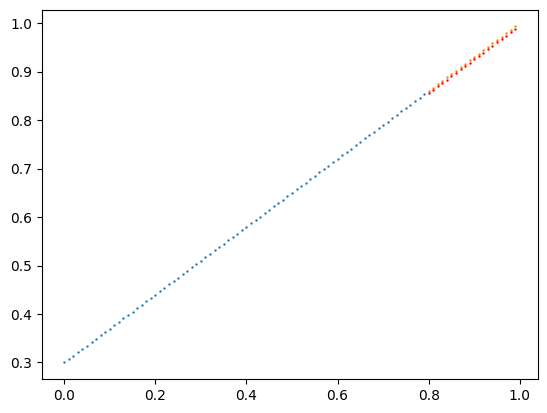

In [ ]:
plt.scatter(x_train_reg.cpu(),y_train_reg.cpu(), s =0.5)
plt.scatter(x_test_reg.cpu(),y_test_reg.cpu(), s =0.5)
plt.scatter(x_test_reg.cpu(),test_pred_reg.cpu(), c='red', s =0.5)

test_pred_reg.size(), y_test_reg.size()

#6. The missing piece: non-linearity
"What patterns could you draw if you were given an infinite amount of a straight and non-straight lines?"
Or in machine learning terms, an infinite (but really its finite) of linear and non-linear functions?

### 6.1 Recreating non-linear data (red and blue circles)


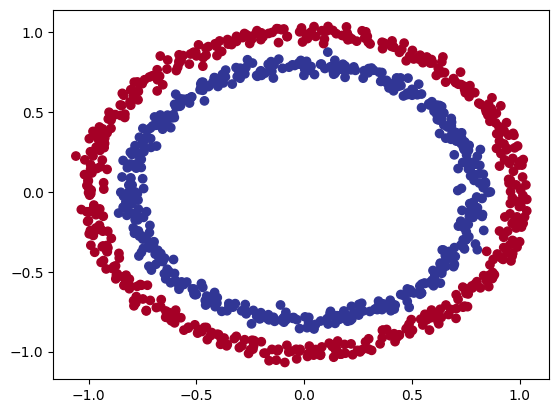

In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

n_samples = 1000

X,y = make_circles(n_samples, noise = 0.03, random_state = 42)

plt.scatter(X[:,0],X[:,1], c= y , cmap = plt.cm.RdYlBu  );

In [ ]:
# Convert data to tensors and to train and test splits
import torch
from sklearn.model_selection import train_test_split

#Turn data into tensors
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

#Split into train and test sets

X_train, X_test , y_train,y_test = train_test_split(X,y, test_size = 0.2, random_state=42)
X_train, X_test , y_train,y_test = X_train.to(device), X_test.to(device) , y_train.to(device), y_test.to(device)
X_train[:5], y_train[:5]

(tensor([[ 0.6579, -0.4651],
         [ 0.6319, -0.7347],
         [-1.0086, -0.1240],
         [-0.9666, -0.2256],
         [-0.1666,  0.7994]], device='cuda:0'),
 tensor([1., 0., 0., 0., 1.], device='cuda:0'))

### 6.2 Building a model with non-linearity
 -> Look at activation functions at torch.nn
  Relu -> takes the input if n is -ve makes it zero else leave as it is

In [ ]:
from torch import nn

class CircleModelV3(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer1 = nn.Linear(in_features =2, out_features = 128)
    self.layer2 = nn.Linear(in_features = 128, out_features = 256)
    self.layer3 = nn.Linear(in_features=256, out_features =256)
    self.layer4 = nn.Linear(in_features=256, out_features =256)
    self.layer5 = nn.Linear(in_features=256, out_features =1)
    self.relu = nn.ReLU()

  def forward(self,x):
    # We made the all -ve values in each layer to zero and left other as it is
    return self.layer5(self.relu(self.layer4(self.relu(self.layer3(self.relu(self.layer2(self.relu(self.layer1(x)))))))))

model_3 = CircleModelV3().to(device)
model_3

CircleModelV3(
  (layer1): Linear(in_features=2, out_features=128, bias=True)
  (layer2): Linear(in_features=128, out_features=256, bias=True)
  (layer3): Linear(in_features=256, out_features=256, bias=True)
  (layer4): Linear(in_features=256, out_features=256, bias=True)
  (layer5): Linear(in_features=256, out_features=1, bias=True)
  (relu): ReLU()
)

In [ ]:
m3_loss_fn = nn.BCEWithLogitsLoss()

m3_optimizer = torch.optim.SGD(model_3.parameters(),lr= 0.1)

In [ ]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 1000

for epoch in range(epochs):
  model_3.train()

  m3_ylogits= model_3(X_train).squeeze()

  m3_ypred_probs = torch.sigmoid(m3_ylogits).to(device)

  m3_ypred_round = torch.round(m3_ypred_probs)

  m3_loss = m3_loss_fn (m3_ylogits,y_train)

  m3_acc = accuracy_fn(y_true=y_train, y_pred = m3_ypred_round)

  m3_optimizer.zero_grad()
  m3_loss.backward()
  m3_optimizer.step()

  model_3.eval()
  with torch.inference_mode():
    m3_test_pred = model_3(X_test).squeeze()
    m3_test_ypred_probs = torch.sigmoid(m3_test_pred).to(device)
    m3_test_ypred_round = torch.round(m3_test_ypred_probs)
    m3_test_loss = m3_loss_fn(m3_test_pred,y_test)
    m3_test_acc = accuracy_fn(y_true=y_test,y_pred=m3_test_ypred_round)

  if epoch %100 == 0 :
    print(f"loss = {m3_loss:.5f} | test loss = {m3_test_loss:.5f} | acc = {m3_acc:.2f} | test acc = {m3_test_acc:.2f} epoch = {epoch}")



loss = 0.69245 | test loss = 0.69235 | acc = 53.87 | test acc = 56.00 epoch = 0
loss = 0.68533 | test loss = 0.68707 | acc = 68.75 | test acc = 67.50 epoch = 100
loss = 0.66304 | test loss = 0.66894 | acc = 82.62 | test acc = 81.00 epoch = 200
loss = 0.56252 | test loss = 0.58038 | acc = 56.12 | test acc = 51.50 epoch = 300
loss = 0.43712 | test loss = 0.50016 | acc = 69.38 | test acc = 60.00 epoch = 400
loss = 0.07123 | test loss = 0.09860 | acc = 100.00 | test acc = 100.00 epoch = 500
loss = 0.01303 | test loss = 0.02582 | acc = 100.00 | test acc = 100.00 epoch = 600
loss = 0.00647 | test loss = 0.01543 | acc = 100.00 | test acc = 100.00 epoch = 700
loss = 0.00417 | test loss = 0.01133 | acc = 100.00 | test acc = 100.00 epoch = 800
loss = 0.00303 | test loss = 0.00912 | acc = 100.00 | test acc = 100.00 epoch = 900


[]

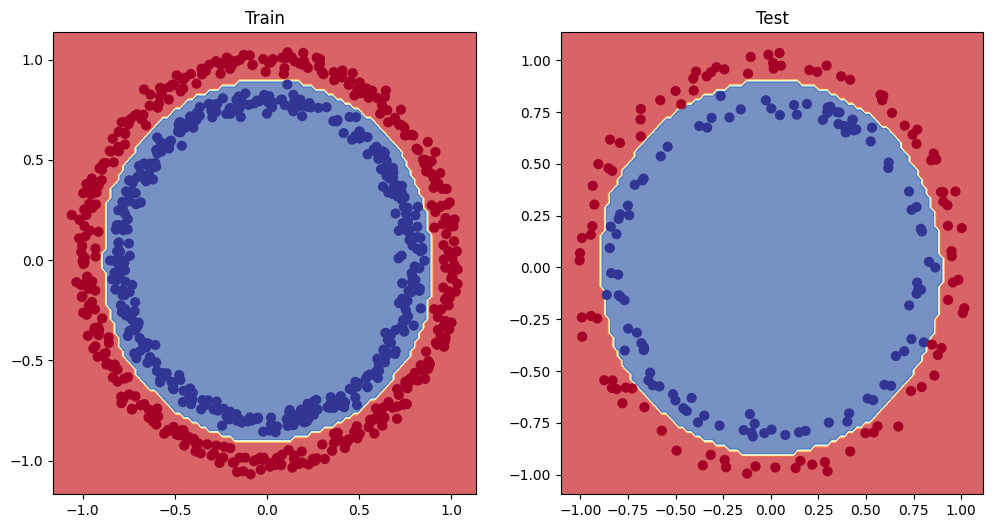

In [ ]:
plt.figure(figsize = (12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_3,X_train,y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_3,X_test,y_test)

plt.plot()


In [ ]:
model_3.state_dict()

OrderedDict([('layer1.weight',
              tensor([[ 0.5733,  0.5984],
                      [-0.2600,  0.7722],
                      [-0.1691,  0.1489],
                      [-0.3444,  0.3893],
                      [ 0.6352, -0.5108],
                      [ 0.5678,  0.1234],
                      [ 0.5353,  0.1112],
                      [ 0.3693, -0.1079],
                      [ 0.5438,  0.1086],
                      [-0.3303,  0.1992],
                      [-0.3900, -0.1128],
                      [-0.4011,  0.5560],
                      [-0.7021, -0.3422],
                      [-0.1997, -0.4252],
                      [ 0.0787, -0.7588],
                      [ 0.7469, -0.7642],
                      [ 0.5092,  0.0986],
                      [-0.2432,  0.4591],
                      [ 0.1239,  0.6340],
                      [ 0.0937, -0.2522],
                      [ 0.1900, -0.1918],
                      [ 0.3311,  0.6747],
                      [ 0.3664, -0.2761],
   

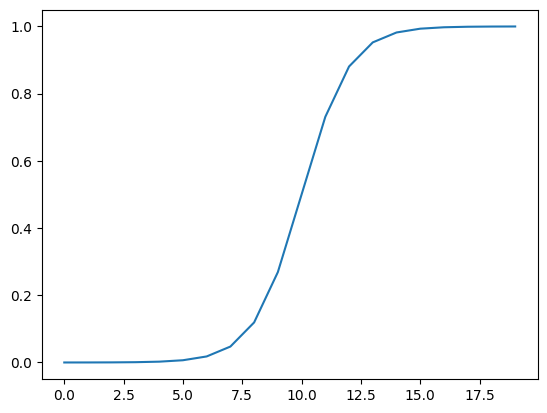

In [ ]:
# Visualizing Activation Function

A = torch.arange(-10,10,1)
A

# Torch.sigmoid
plt.plot(torch.sigmoid(A))

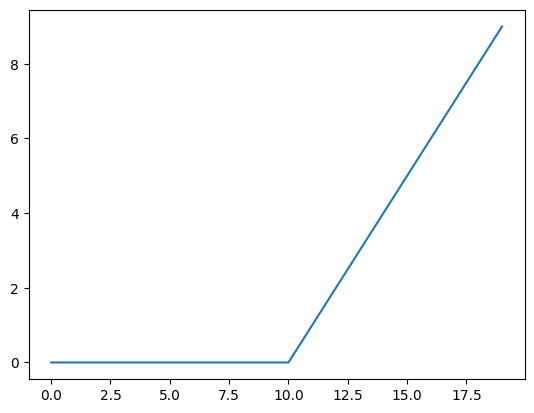

In [ ]:
# Torch.relu()
plt.plot(torch.relu(A))

# Putting it all together with a multi-class classification problem

* Binary classification = one thing or another (cat vs dog, spam vs not spam, fraud or not fraud)
* Multi-class Classification = more than one thing or another (vat vs. dog vs. chicken)

In [ ]:
import torch
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

In [ ]:
NUM_CLASSES = 4
NUM_FEATURES = 2
RANDOM_SEED = 42

X_blob,y_blob = make_blobs(n_samples = 1000, n_features = NUM_FEATURES,centers = NUM_CLASSES , cluster_std = 1.5, random_state = RANDOM_SEED)

In [ ]:
X_blob[:5]

array([[-8.41339595,  6.93516545],
       [-5.76648413, -6.43117072],
       [-6.04213682, -6.76610151],
       [ 3.95083749,  0.69840313],
       [ 4.25049181, -0.28154475]])

In [ ]:
X_blob = torch.from_numpy(X_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.LongTensor)

X_train,X_test, y_train,y_test = train_test_split(X_blob,y_blob,test_size = 0.2 ,random_state = RANDOM_SEED)

X_train.size() , y_train.size()

(torch.Size([800, 2]), torch.Size([800]))

In [ ]:
y_blob.size()

torch.Size([1000])

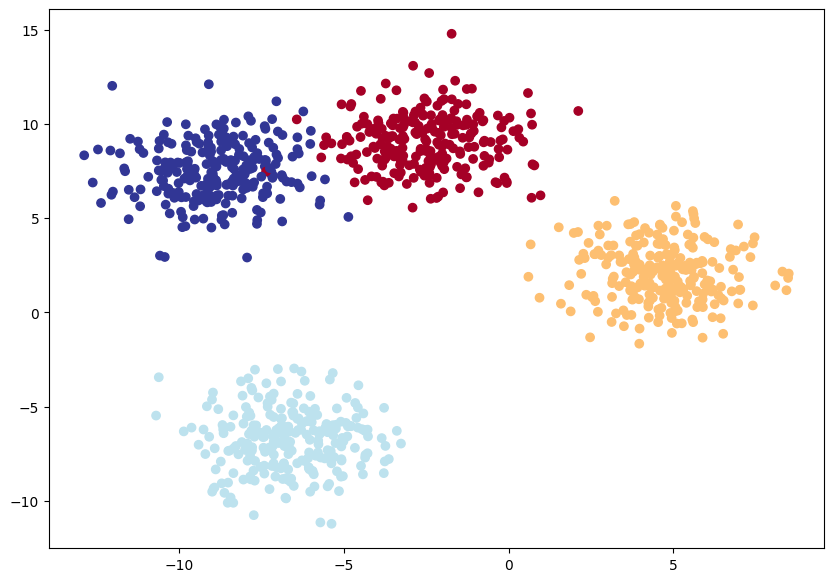

In [ ]:
plt.figure(figsize=(10,7))
plt.scatter(X_blob[:,0],X_blob[:,1], c= y_blob, cmap = plt.cm.RdYlBu)

## 8.2 Building a multi-class classification model in Pytorch

In [ ]:
# Create device agnostic code
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [ ]:
# Build multiclass classification model

class BlobModel(nn.Module):

  def __init__(self, input_features, output_features, hidden_units = 8):

    """ Initializes multi-class classification model.

    Args:
      input_features(int): Number of input features to the model
      output_features(int): Number of output features (number of output classes)
      hidden_unites(int): Number of hidden unites between layers, default 8

    Returs :
    Eaxmple:
    """
    super().__init__(

    )

    self.linear_stack_layer = nn.Sequential(
        nn.Linear(in_features = input_features, out_features = hidden_units),
        nn.ReLU(),
        nn.Linear(in_features = hidden_units, out_features = hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units, out_features = output_features)
    )

  def forward(self,x):
    return self.linear_stack_layer(x)

model_4 = BlobModel(input_features = 2, output_features=4, hidden_units = 8).to(device) # Out_features = no of classes
model_4

BlobModel(
  (linear_stack_layer): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=4, bias=True)
  )
)

In [ ]:
### 8.3 Create a loss funtion and an optimizer for a multi-class classification
loss_fn = nn.CrossEntropyLoss()

# Optimizer
optimizer = torch.optim.SGD(params = model_4.parameters(), lr = 0.1)

In [ ]:
# The raw, unnormalized output scores from a model—specifically before they are
# transformed into probabilities by an activation function (like Softmax or Sigmoid)—are called logits
model_4.eval()
with torch.inference_mode():
  y_logits = model_4(X_test.to(device))
y_logits[:10]

tensor([[-0.7646, -0.7412, -1.5777, -1.1376],
        [-0.0973, -0.9431, -0.5963, -0.1371],
        [ 0.2528, -0.2379,  0.1882, -0.0066],
        [-0.4134, -0.5204, -0.9303, -0.6963],
        [-0.3118, -1.3736, -1.1991, -0.3834],
        [-0.1497, -1.0617, -0.7107, -0.1645],
        [ 0.1539, -0.2887,  0.1520, -0.0109],
        [-0.2154, -1.1795, -0.9300, -0.2745],
        [ 0.2443, -0.2472,  0.1649,  0.0061],
        [-0.2329, -1.2120, -0.9849, -0.3004]], device='cuda:0')

In [ ]:
# Convert model's logit outputs to prediction probabilities
y_pred_probs = torch.softmax(y_logits, dim=1) #It makes the logits sum upto 1.
y_pred_probs[:5],y_logits[:5]
# The output represents the probabilites of features belongs to the 4 classes, the max value in a row represents the features most likely to belongs to that class
# Example max(first row) = 3169 so, the features of first row belongs to class 0

(tensor([[0.3169, 0.3244, 0.1405, 0.2182],
         [0.3336, 0.1432, 0.2026, 0.3206],
         [0.3011, 0.1843, 0.2823, 0.2323],
         [0.3078, 0.2766, 0.1836, 0.2320],
         [0.3719, 0.1286, 0.1532, 0.3463]], device='cuda:0'),
 tensor([[-0.7646, -0.7412, -1.5777, -1.1376],
         [-0.0973, -0.9431, -0.5963, -0.1371],
         [ 0.2528, -0.2379,  0.1882, -0.0066],
         [-0.4134, -0.5204, -0.9303, -0.6963],
         [-0.3118, -1.3736, -1.1991, -0.3834]], device='cuda:0'))

In [ ]:
# Convert model's prediction probabilities to prediction labels
y_preds = torch.argmax(y_pred_probs,dim=1)
y_preds[:]

tensor([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 3, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
        1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 1, 0, 1, 0, 0, 0,
        0, 0, 0, 0, 3, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
        1, 0, 0, 0, 0, 1, 0, 1], device='cuda:0')

### 8.4 Getting prediction probabilities for a multi-class PytTorch Model

In [ ]:
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed(RANDOM_SEED)

X_train,X_test, y_train,y_test = X_train.to(device),X_test.to(device), y_train.to(device),y_test.to(device)

epochs = 1000
for epoch in range(epochs):

  model_4.train()

  y_logits = model_4(X_train)

  y_preds = torch.softmax(y_logits,dim=1).argmax(dim=1)
  loss = loss_fn(y_logits, y_train)

  acc = accuracy_fn(y_true = y_train, y_pred = y_preds)

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  model_4.eval()

  with torch.inference_mode():
    test_pred_blob= model_4(X_test)
    test_pred = torch.softmax(test_pred_blob, dim = 1).argmax(dim=1)
    test_loss = loss_fn(test_pred_blob, y_test)

    test_acc = accuracy_fn(y_pred=test_pred, y_true=y_test)

  if epoch%100 == 0:
    print(f'loss : {loss:.2f} acc : {acc:.2f} | test loss : {test_loss:.2f} "test_acc :{test_acc:.2f} | epochs = {epoch}  ')



loss : 1.16 acc : 40.38 | test loss : 1.08 "test_acc :48.00 | epochs = 0  
loss : 0.03 acc : 99.25 | test loss : 0.02 "test_acc :99.50 | epochs = 100  
loss : 0.03 acc : 99.25 | test loss : 0.02 "test_acc :99.50 | epochs = 200  
loss : 0.03 acc : 99.25 | test loss : 0.01 "test_acc :99.50 | epochs = 300  
loss : 0.02 acc : 99.25 | test loss : 0.01 "test_acc :99.50 | epochs = 400  
loss : 0.02 acc : 99.25 | test loss : 0.01 "test_acc :99.50 | epochs = 500  
loss : 0.02 acc : 99.25 | test loss : 0.01 "test_acc :99.50 | epochs = 600  
loss : 0.02 acc : 99.25 | test loss : 0.01 "test_acc :99.50 | epochs = 700  
loss : 0.02 acc : 99.25 | test loss : 0.01 "test_acc :99.50 | epochs = 800  
loss : 0.02 acc : 99.25 | test loss : 0.01 "test_acc :99.50 | epochs = 900  


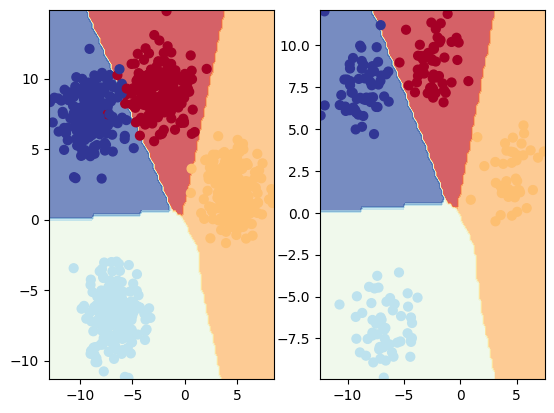

In [ ]:
plt.subplot(1,2,1)
plot_decision_boundary(model_4,X_train,y_train)
plt.subplot(1,2,2)
plot_decision_boundary(model_4,X_test,y_test)